In [ ]:
!pip install cobra

In [ ]:

import sys
if "google.colab" in sys.modules:
    !wget "https://raw.githubusercontent.com/IDAES/idaes-pse/main/scripts/colab_helper.py"
    import colab_helper
    colab_helper.install_idaes()
    colab_helper.install_ipopt()

import pyomo.environ as pyo
from pyomo.environ import *
import time
import pandas as pd
import re

This is a toy model in which species 1 has a medium composition of [c:2, d:1]. Under this diet, species 1 has a maximum growth rate of 1 h⁻¹.
Species 2 has a medium composition of [a:2, b:1] and, under this diet, also achieves a growth rate of 1 h⁻¹.

 **With this model, we demonstrate that MOFA can predict positive interactions.**

**1. First, under these media conditions, we compute the maximum growth rate of each species using FBA.**

**2.Then, we merge the two species into a community model and define the medium of the merged model as [a:2, b:1, c:2, d:1].**

**3.We compute the growth rate of each species using MOFA.**



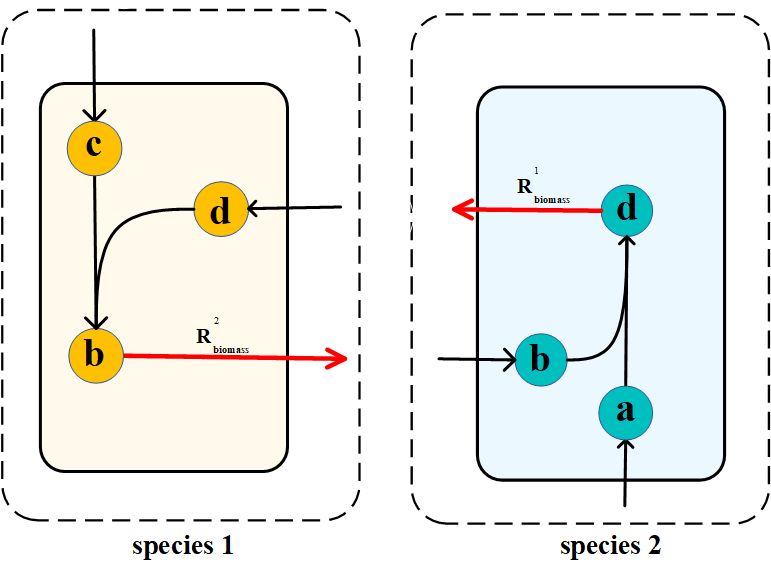

# Create these two toy model

In [14]:
from cobra import Model, Reaction, Metabolite

# Create model
model1 = Model("SP1_model")

# Metabolites
c = Metabolite("c", compartment="c")
d = Metabolite("d", compartment="c")
b = Metabolite("b", compartment="c")

# Reactions

# R1 (EX_c)
r1 = Reaction("EX_c")
r1.lower_bound = 0
r1.upper_bound = 2
r1.add_metabolites({c: 1})

# R2 (EX_d)
r2 = Reaction("EX_d")
r2.lower_bound = 0
r2.upper_bound = 2
r2.add_metabolites({d: 1})

# R3 (v)
r3 = Reaction("v")
r3.lower_bound = -2
r3.upper_bound = 2
r3.add_metabolites({
    c: -1,
    d: -1,
    b: 1
})

# R4 (biomass)
r4 = Reaction("EX_b")
r4.lower_bound = 0
r4.upper_bound = 4
r4.add_metabolites({b: -1})

# Add reactions to model
model1.add_reactions([r1, r2, r3, r4])

# Set objective
model1.objective = r4

r2.upper_bound = 1
# Optimize
solution = model1.optimize()
print("FBA:  Maximum growth rate species1 =", solution.objective_value)
r2.upper_bound = 2

FBA:  Maximum growth rate species1 = 1.0


In [16]:
from cobra import Model, Reaction, Metabolite

model2 = Model("SP1_model_2")

# Metabolites
a = Metabolite("a", compartment="c")
b = Metabolite("b", compartment="c")
d = Metabolite("d", compartment="c")

# Reactions

# R1 (EX_a)
r1 = Reaction("EX_a")
r1.lower_bound = 0
r1.upper_bound = 2
r1.add_metabolites({a: 1})

# R2 (EX_b)
r2 = Reaction("EX_b")
r2.lower_bound = 0
r2.upper_bound = 1
r2.add_metabolites({b: 1})

# R3 (v)
r3 = Reaction("v")
r3.lower_bound = -2
r3.upper_bound = 2
r3.add_metabolites({
    a: -1,
    b: -1,
    d: 1
})

# R4 (biomass)
r4 = Reaction("EX_d")
r4.lower_bound = 0
r4.upper_bound = 4
r4.add_metabolites({d: -1})

model2.add_reactions([r1, r2, r3, r4])

model2.objective = r4

solution = model2.optimize()
print("FBA:  Maximum growth rate species2 =", solution.objective_value)
r2.upper_bound = 2

FBA:  Maximum growth rate species2 = 1.0


In [5]:
from cobra.util.array import create_stoichiometric_matrix
import numpy as np
from cobra import Model, Reaction, Metabolite

def add_model_to_community(model, communitymodel, species_id):

  EX_1 = [i for i, rxn in enumerate(model.reactions) if 'EX_' in rxn.id]
  EX_2 = [i for i, rxn in enumerate(communitymodel.reactions) if 'EX_' in rxn.id]

  i1, _ = np.where(create_stoichiometric_matrix(model)[:, EX_1] != 0)
# community model
  i2, _ = np.where(create_stoichiometric_matrix(communitymodel)[:, EX_2] != 0)


  mets_1 = {
    met.id
    for rxn in model.reactions if 'EX_' in rxn.id
    for met in rxn.metabolites
  }
  mets_2 = {
    met.id.split('_species')[0]
    for rxn in communitymodel.reactions if 'EX_' in rxn.id
    for met in rxn.metabolites
   }

  shared_mets = list(set(mets_1) & set(mets_2))


  for i_loop in range(len(shared_mets)):
     met1_index = next(
        i for i, met in enumerate(model.metabolites)
        if met.id == shared_mets[i_loop]
     )

    # reactions involving this metabolite
     temp = np.where(create_stoichiometric_matrix(model)[met1_index, :] != 0)[0]
    # exchange reactions involving this metabolite
     rxn1_index = [
        j for j in temp
        if 'EX_' in model.reactions[j].id
     ]

     if model.reactions[rxn1_index[0]].lower_bound < 0 and model.reactions[rxn1_index[0]].upper_bound > 0:

      # Check if the reaction exports the metabolite (negative stoichiometric coefficient)
      if model.reactions[rxn1_index[0]].get_coefficient(model.metabolites[met1_index])<0:

          new_rxn = Reaction('EX_uptake_' + model.reactions[rxn1_index[0]].id.split('EX_')[1])
          new_rxn.lower_bound = 0
          new_rxn.upper_bound = -1 * model.reactions[rxn1_index[0]].lower_bound


          # Set the stoichiometry for the metabolite
          rxn = model.reactions[rxn1_index[0]]  # get the reaction object
          met = model.metabolites[met1_index]   # get the metabolite object
          stoich_coeff = rxn.get_coefficient(met)  # negative if metabolite is consumed

          new_rxn.add_metabolites({met: -1 * stoich_coeff})

          # Add new reaction to the model
          model.add_reactions([new_rxn])
          new_rxn.objective_coefficient = 0
          # Rename the original reaction to EX_export_...
          model.reactions[rxn1_index[0]].id = 'EX_export_' + model.reactions[rxn1_index[0]].id.split('EX_')[1]
          model.reactions[rxn1_index[0]].lower_bound = 0
      else:

          new_rxn = Reaction('EX_export_' + model.reactions[rxn1_index[0]].id.split('EX_')[1])
          new_rxn.lower_bound = 0
          new_rxn.upper_bound = -1 * model.reactions[rxn1_index[0]].lower_bound
          new_rxn.objective_coefficient = 0

          # Set the stoichiometry for the metabolite
          rxn = model.reactions[rxn1_index[0]]  # get the reaction object
          met = model.metabolites[met1_index]   # get the metabolite object
          stoich_coeff = rxn.get_coefficient(met)  # negative if metabolite is consumed

          new_rxn.add_metabolites({met: -1 * stoich_coeff})
          # Add new reaction to the model
          model.add_reactions([new_rxn])
          # Rename the original reaction to EX_export_...


     elif  model.reactions[rxn1_index[0]].get_coefficient(model.metabolites[met1_index])<0:
      model.reactions[rxn1_index[0]].id = 'EX_export_' + model.reactions[rxn1_index[0]].id.split('EX_')[1]
     else:
      model.reactions[rxn1_index[0]].id = 'EX_uptake_' + model.reactions[rxn1_index[0]].id.split('EX_')[1]

 #--------------------------------------------------------------------------------------------------
#                                             second model
 #---------------------------------------------------------------------------------------------------


     mets_base = [m.id.split('_species')[0] for m in communitymodel.metabolites]

     # find metabolite index
     met2_index_arr = np.where(np.array(mets_base) == shared_mets[i_loop])[0]
     met2_index = met2_index_arr[0]

     # find reactions involving this metabolite
     S_comm = create_stoichiometric_matrix(communitymodel)
     temp = np.where(S_comm[met2_index, :] != 0)[0]

    # exchange reactions involving this metabolite
     rxn2_index = [
        j for j in temp
        if 'EX_' in communitymodel.reactions[j].id
     ]
     rxn_ids = np.array([rxn.id for rxn in communitymodel.reactions])

     if not np.any(np.char.find(rxn_ids[rxn2_index], '_[Env]') != -1):
      if communitymodel.reactions[rxn2_index[0]].lower_bound < 0 and communitymodel.reactions[rxn2_index[0]].upper_bound > 0:

      # Check if the reaction exports the metabolite (negative stoichiometric coefficient)
       if communitymodel.reactions[rxn2_index[0]].get_coefficient(communitymodel.metabolites[met2_index])<0:

          rxn2_origin=communitymodel.reactions[rxn2_index[0]].id.split('EX_')[1]
          oldlb=communitymodel.reactions[rxn2_index[0]].lower_bound
           # Rename the original reaction to EX_export_...
          communitymodel.reactions[rxn2_index[0]].id = 'EX_export_' +rxn2_origin
          communitymodel.reactions[rxn2_index[0]].lower_bound = 0

          new_rxn = Reaction('EX_uptake_' + rxn2_origin)
          new_rxn.lower_bound = 0
          new_rxn.upper_bound = -1 * oldlb

        # Set the stoichiometry for the metabolite
          rxn = communitymodel.reactions[rxn2_index[0]]  # get the reaction object
          met = communitymodel.metabolites[met2_index]   # get the metabolite object
          stoich_coeff = rxn.get_coefficient(met)  # negative if metabolite is consumed
          new_rxn.add_metabolites({met: -1 * stoich_coeff})
          # Add new reaction to the model
          communitymodel.add_reactions([new_rxn])
          new_rxn.objective_coefficient = 0


       else: # coeffeient  > 0

          rxn2_origin=communitymodel.reactions[rxn2_index[0]].id.split('EX_')[1]
           # Rename the original reaction to EX_export_...
          communitymodel.reactions[rxn2_index[0]].id = 'EX_uptake_' + rxn2_origin
          oldlb=communitymodel.reactions[rxn2_index[0]].lower_bound;
          communitymodel.reactions[rxn2_index[0]].lower_bound = 0

          new_rxn = Reaction('EX_export_' + rxn2_origin)
          new_rxn.lower_bound = 0
          new_rxn.upper_bound = -1 * oldlb


          # Set the stoichiometry for the metabolite
          rxn = communitymodel.reactions[rxn2_index[0]]  # get the reaction object
          met = communitymodel.metabolites[met2_index]   # get the metabolite object
          stoich_coeff = rxn.get_coefficient(met)  # negative if metabolite is consumed

          new_rxn.add_metabolites({met: -1 * stoich_coeff})
          # Add new reaction to the model
          communitymodel.add_reactions([new_rxn])
          new_rxn.objective_coefficient = 0


      elif  communitymodel.reactions[rxn2_index[0]].get_coefficient(communitymodel.metabolites[met2_index])<0:
       communitymodel.reactions[rxn2_index[0]].id = 'EX_export_' + communitymodel.reactions[rxn2_index[0]].id.split('EX_')[1]
      else:
       communitymodel.reactions[rxn2_index[0]].id = 'EX_uptake_' + communitymodel.reactions[rxn2_index[0]].id.split('EX_')[1]

################################################################################
##                      Merge models
################################################################################
  communitymodel = merge_models_block_diagonal(communitymodel, model, prefix2="_species2")

  for i_loop in range(len(shared_mets)):
    mets_base = [m.id.split('_species')[0] for m in communitymodel.metabolites]
    met_index_arr = np.where(np.array(mets_base) == shared_mets[i_loop])[0]
    met_index = met_index_arr
    temp = np.where(np.any(create_stoichiometric_matrix(communitymodel)[met_index, :] != 0, axis=0))[0]
    rxn_index = [
    j for j in temp
    if 'EX_' in communitymodel.reactions[j].id
    ]

    if not any('_[Env]' in communitymodel.reactions[i].id for i in rxn_index):

      env_met_id = f"{shared_mets[i_loop]}"
      if env_met_id not in [m.id for m in communitymodel.metabolites]:
        env_met = Metabolite(
        id=env_met_id,
        name=env_met_id,
        compartment="e"
        )
        communitymodel.add_metabolites([env_met])

        rxn_id = f"EX_export_{shared_mets[i_loop]}_[Env]"
        new_rxn = Reaction(rxn_id)
        new_rxn.lower_bound = 0
        new_rxn.upper_bound = 1000
        new_rxn.add_metabolites({ env_met: -1})
        communitymodel.add_reactions([new_rxn])

        rxn_id = f"EX_uptake_{shared_mets[i_loop]}_[Env]"
        new_rxn = Reaction(rxn_id)
        new_rxn.lower_bound = 0
        new_rxn.upper_bound = 1000
        new_rxn.add_metabolites({ env_met: 1})
        communitymodel.add_reactions([new_rxn])

        for idx in rxn_index:
          rxn = communitymodel.reactions[idx]
          rxn.id = 'EXCom_' + rxn.id.split('EX_')[-1]

          jj = np.where(create_stoichiometric_matrix(communitymodel)[:, idx] != 0)[0]

          met = communitymodel.metabolites[jj[0]]   # get the metabolite object

          stoich_coeff = rxn.get_coefficient(met)  # negative if metabolite is consumed
          print(met, " r: ",rxn, "  ",stoich_coeff)
          rxn.add_metabolites({env_met:  -1 * stoich_coeff})

          if '_species' not in met.id:
            suffix = rxn.id.split('_species', 1)[1]
            met.id = met.id + '_species' + suffix



    else:
      rxn = [j for j in rxn_index if 'species' in communitymodel.reactions[j].id]
      for j in rxn:
       old_id = communitymodel.reactions[j].id
       if 'EX_' in old_id:
         communitymodel.reactions[j].id = 'EXCom_' + old_id.split('EX_')[1]

      ii= np.where(create_stoichiometric_matrix(communitymodel)[:,  rxn[0] ] != 0)[0]

      rxn_ids = np.array([rxn.id for rxn in communitymodel.reactions])
      temp = np.where(np.char.find(rxn_ids[rxn_index], "_[Env]") != -1)[0]

      for j_idx in rxn:
       rxn_obj = communitymodel.reactions[j_idx]


       main_met = communitymodel.metabolites[ii]
       env_met = communitymodel.metabolites[jj[0]]

       coeff = rxn_obj.get_coefficient(main_met)
       rxn_obj.add_metabolites({env_met: -coeff})


  return communitymodel



In [6]:
from cobra import Model
from cobra.util.solver import linear_reaction_coefficients
import copy

def merge_models_block_diagonal(model1, model2, prefix2="m2_"):
    """
    Merge two COBRA models with NO shared metabolites or reactions.
    Reactions and metabolites of model2 are appended after model1.
    """

    # کپی عمیق
    m1 = model1.copy()
    m2 = model2.copy()

    # ---------- rename metabolites of model2 ----------
    for met in m2.metabolites:
        met.id =  met.id + prefix2

    # ---------- rename reactions of model2 ----------
    for rxn in m2.reactions:
        rxn.id =  rxn.id + prefix2

    # ---------- add metabolites ----------
    m1.add_metabolites(m2.metabolites)

    # ---------- add reactions ----------
    m1.add_reactions(m2.reactions)


    return m1

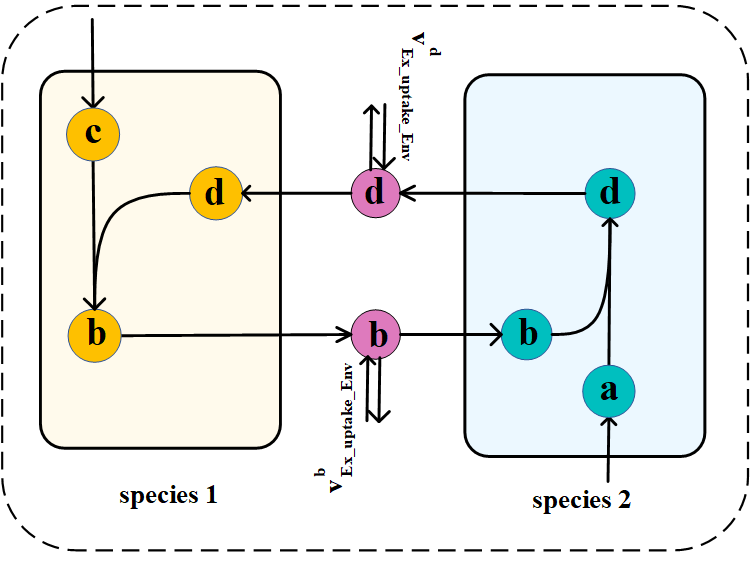

**Merge these two models and set the diet as follows:**

[Ex_uptake<sup>a</sup> = 2,
 Ex_uptake<sup>c</sup> = 2,
 Ex_uptake_Env<sup>b</sup> = 1,
 Ex_uptake_Env<sup>d</sup> = 1]

In [ ]:
# List of model names
communitymodel=model1
for rxn in communitymodel.reactions:
    rxn.id += "_species1"

for met in communitymodel.metabolites:
    met.id += "_species1"
 # Python index starts at 0
    #model = read_sbml_model(f"{SAVEDIR}/{models_name[i]}.xml")
communitymodel = add_model_to_community(
        model2,
        communitymodel,
        species_id=2
    )


In [18]:
import numpy as np
import pandas as pd
import re
import copy
import pyomo.environ as pyo
from pyomo.environ import *

m,n=create_stoichiometric_matrix(communitymodel).shape

rxns = [rxn.id for rxn in communitymodel.reactions]
mets = [met.id for met in communitymodel.metabolites]

S = create_stoichiometric_matrix(communitymodel, array_type='dense')
Sij = pd.DataFrame(
    S,
    index=mets,
    columns=rxns
)


lb = [rxn.lower_bound for rxn in communitymodel.reactions]
ub = [rxn.upper_bound for rxn in communitymodel.reactions]

rxn.upper_bound = 0
rxn = communitymodel.reactions.get_by_id('EX_uptake_b_[Env]')
rxn.upper_bound = 1

rxn = communitymodel.reactions.get_by_id('EX_uptake_d_[Env]')
rxn.upper_bound = 1

In [19]:

import pyomo.environ as pyo
from pyomo.environ import *
import time
import pandas as pd
import re

substring='EXCom_uptake'
indices = [i for i, s in enumerate(rxns) if substring in s]
uptake_rxns_indices = [rxns[i] for i in indices]

uptake_species1 = [n for n in uptake_rxns_indices if 'species1' in n]

uptake_species2=[n for n in uptake_rxns_indices if 'species2' in n]

substring='EXCom_export'
indices = [i for i, s in enumerate(rxns) if substring in s]
export_rxns_indices = [rxns[i] for i in indices]

big_M=10000000000000

Exc_indice = [i for i, s in enumerate(rxns) if 'EXCom_' in s]
Exc = [rxns[i] for i in Exc_indice]

F1=1
F2=1


model = ConcreteModel()

model.N = Set(initialize=rxns)

model.M = Set(initialize=mets)

biomass_id=['EXCom_export_b_species1','EXCom_export_d_species2']


model.biomass = Set(initialize=biomass_id, within=model.N)

model.uptake_rxns_species1=Set(initialize=uptake_species1,within=model.N)

model.uptake_rxns_species2=Set(initialize=uptake_species2,within=model.N)

model.export_rxns=Set(initialize=export_rxns_indices,within=model.N)

 ##############################################################################################
    #              Create Parameters
 ##############################################################################################

model.lb = pyo.Param(model.N, initialize={rxn: lb[j]  for j, rxn in enumerate(rxns)})
model.ub = pyo.Param(model.N, initialize={rxn: ub[j]  for j, rxn in enumerate(rxns)})

 ##############################################################################################
    #              Create Variables
##############################################################################################

index_to_list = {k: i for i, k in enumerate(model.N)}

def variable_bounds_from_list(model, index):
  idx = index_to_list[index]
  lower_bound = lb[idx]
  upper_bound = ub[idx]

  return (lower_bound, upper_bound)

model.v = pyo.Var(model.N, bounds=variable_bounds_from_list)

model.u_1=pyo.Var(model.N)

model.lamda_1=pyo.Var(model.M)

model.eta_UB_1=pyo.Var(model.N,domain=pyo.NonNegativeReals)

model.eta_LB_1=pyo.Var(model.N,domain=pyo.NonNegativeReals)


model.u_2=pyo.Var(model.N)

model.lamda_2=pyo.Var(model.M)

model.eta_UB_2=pyo.Var(model.N,domain=pyo.NonNegativeReals)

model.eta_LB_2=pyo.Var(model.N,domain=pyo.NonNegativeReals)

##############################################################################################
    #                   The objective function
##############################################################################################

model.obj=pyo.Objective(expr=sum(model.v[i] for i in model.biomass), sense=pyo.maximize)

#S = {(r, c): Sij.at[r, c] * ( F1 if 'species1' in c else F2 ) if c in Exc else Sij.at[r, c] for r in Sij.index for c in Sij.columns}
S = {(r, c):Sij.at[r,c] for r in  Sij.index for c in Sij.columns}

def massbalance_rule(model,m):
     return sum(S[m,n]*model.v[n] for n in model.N)==0
model.massbalance=pyo.Constraint(model.M,rule=massbalance_rule)


model.Biomass_species1=pyo.Constraint(expr=model.v[biomass_id[0]]>= model.u_1[biomass_id[0]] )

model.Biomass_species2=pyo.Constraint(expr=model.v[biomass_id[1]]>=model.u_2[biomass_id[1]] )
big_M=100000000

def Export_couple_Biomass_rule(model, export):
     if 'species1' in export:
        return model.v[export] <= big_M* model.v[biomass_id[0]]
     return model.v[export] <= big_M* model.v[biomass_id[1]]

model.Export_couple_biomass=pyo.Constraint(model.export_rxns,rule=Export_couple_Biomass_rule)


def Zero_const_species_rule(model, r):
     if r in uptake_rxns_indices:
        rr = r.replace('uptake', 'export')

        # check that the export reaction exists
        if rr in model.v:
            return model.v[r] * model.v[rr] == 0
        else:
            return pyo.Constraint.Skip
     else:
        return pyo.Constraint.Skip
model.zero_const = pyo.Constraint(model.N, rule=Zero_const_species_rule)

""" model.zero_const = pyo.Constraint(
    expr=sum(
        model.v[r] * model.v[e]
        for r in uptake_rxns_indices
        for e in [r.replace('uptake', 'export')]
        if e in model.v
    ) == 0
) """

##############################################################################################
    #                   (Inner-problem species1) constraint F.A for species 1
###############################################################################################
def massbalance_species1_rule(model,m):
     return sum(S[m,n]*model.u_1[n] for n in model.N)==0

model.massbalance_species1=pyo.Constraint(model.M,rule=massbalance_species1_rule)  #Su^1=0

def UB_const_species1_rule(model, r):
        if r not in model.uptake_rxns_species1:
            return model.u_1[r] <= model.ub[r]
        return  model.u_1[r] <= model.v[r]
model.ub_species1= pyo.Constraint(model.N, rule=UB_const_species1_rule)

def LB_const_species1_rule(model, r):
     return -1*model.u_1[r] <= -1*model.lb[r]
model.lb_species1= pyo.Constraint(model.N, rule=LB_const_species1_rule)


i_biomass=0
def dual_const_species1_rule(model, n):
    if n not in  biomass_id[i_biomass]:
        return sum(S[m,n]*model.lamda_1[m] for m in model.M)+ model.eta_UB_1[n]-model.eta_LB_1[n]==0

    return sum(S[m,biomass_id[i_biomass]]*model.lamda_1[m] for m in model.M)+model.eta_UB_1[biomass_id[i_biomass]]-model.eta_LB_1[biomass_id[i_biomass]]==1

model.dual_species1= pyo.Constraint(model.N, rule=dual_const_species1_rule)

model.dual_eq_primal_species1=pyo.Constraint(expr= (sum(model.v[n]*model.eta_UB_1[n] for n in model.uptake_rxns_species1)+ \
                  sum(-1*model.lb[n]*model.eta_LB_1[n]  for n in model.uptake_rxns_species1)+ \
                  sum(model.ub[n]*model.eta_UB_1[n] for n in model.N if n not in model.uptake_rxns_species1)+\
                  sum(-1*model.lb[n]*model.eta_LB_1[n] for n in model.N if n not in model.uptake_rxns_species1))==model.u_1[biomass_id[i_biomass]])

 ##############################################################################################
    #                   (Inner-problem species2) constraint F.A for species 2
###############################################################################################

def massbalance_species2_rule(model,m):
    return sum(S[m,n]*model.u_2[n] for n in model.N)==0
model.massbalance_species2=pyo.Constraint(model.M,rule=massbalance_species2_rule)

def UB_const_species2_rule(model, r):
    if r not in model.uptake_rxns_species2:
        return model.u_2[r] <= model.ub[r]
    return model.u_2[r] <= model.v[r]
model.ub_species2= pyo.Constraint(model.N, rule=UB_const_species2_rule)

def LB_const_species2_rule(model, r):
      return -1*model.u_2[r] <= -1*model.lb[r]
model.lb_species2= pyo.Constraint(model.N, rule=LB_const_species2_rule)

i_biomass=1
def dual_const_species2_rule(model, n):
    if n not in  biomass_id[i_biomass]:
       return sum(S[m,n]*model.lamda_2[m] for m in model.M)+ model.eta_UB_2[n]-model.eta_LB_2[n]==0
    return sum(S[m,biomass_id[i_biomass]]*model.lamda_2[m] for m in model.M)+ \
            model.eta_UB_2[biomass_id[i_biomass]] -model.eta_LB_2[biomass_id[i_biomass]]==1

model.dual_species2= pyo.Constraint(model.N, rule=dual_const_species2_rule)

model.dual_eq_primal_species2=pyo.Constraint(expr= (sum(model.v[n]*model.eta_UB_2[n] for n in model.uptake_rxns_species2)+ \
                  sum(-1*model.lb[n]*model.eta_LB_2[n] for n in model.uptake_rxns_species2)+ \
                  sum(model.ub[n]*model.eta_UB_2[n] for n in model.N if n not in model.uptake_rxns_species2)+\
                  sum(-1*model.lb[n]*model.eta_LB_2[n] for n in model.N if n not in model.uptake_rxns_species2))==model.u_2[biomass_id[i_biomass]])


# solve using the nonlinear solver ipopt
result = pyo.SolverFactory('ipopt',executable='/root/.idaes/bin/ipopt').solve(model)

print(f"Community growth rate:", value(model.obj) ,'  Solver status: ', result.solver.status)
print("In the community, Species 1's growth: ", value(model.v[biomass_id[0]]),"Species 1's growth",value(model.v[biomass_id[1]]),'  ',  )





Community growth rate: 4.000000024968504   Solver status:  ok
In the community, Species 1's growth:  2.000000012484252 Species 1's growth 2.000000012484252   


The growth rate of each species in the community is higher than in the individual model. This is because, in addition to metabolites d and b available in the environment (1 mmol/gDW), each species exports 1 mmol of metabolites b and d, resulting in 2 mmol/gDW available for each species.

In [ ]:
!which ipopt